# Ejercicio 2

1. En la imagen `cuadros.tif` se observa un conjunto de cuadros negros sobre un fondo casi uniforme. Utilice ecualización local del histograma para revelar los detalles ocultos en la imagen y compare los resultados con los obtenidos con ecualización global.
Ayuda: el tamaño de ventana y su localización es clave para realizar la ecualización local.

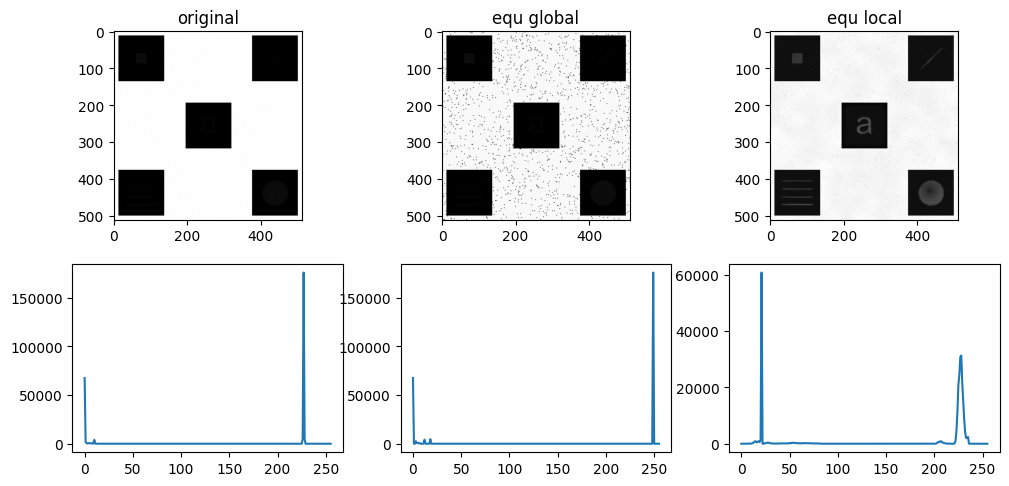

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

cuadros = cv2.imread("cuadros.tif", cv2.IMREAD_GRAYSCALE)

equ_cuadros = cv2.equalizeHist(cuadros)

clahe = cv2.createCLAHE(clipLimit=20.0, tileGridSize=(16,16))
clahe_cuadros = clahe.apply(cuadros)

histr = cv2.calcHist([cuadros], channels=[0], mask=None, histSize=[256], ranges=[0, 255])
equ_histr = cv2.calcHist([equ_cuadros], channels=[0], mask=None, histSize=[256], ranges=[0, 255])
clahe_histr = cv2.calcHist([clahe_cuadros], channels=[0], mask=None, histSize=[256], ranges=[0, 255])

fig, ax = plt.subplots(2, 3)
fig.set_figwidth(15)
fig.set_figwidth(10)
fig.tight_layout()

ax[0][0].set_title('original')
ax[0][0].imshow(cuadros, cmap='gray')
ax[0][1].set_title('equ global')
ax[0][1].imshow(equ_cuadros, cmap='gray')
ax[0][2].set_title('equ local')
ax[0][2].imshow(clahe_cuadros, cmap='gray')
ax[1][0].plot(histr)
ax[1][1].plot(equ_histr)
ax[1][2].plot(clahe_histr);

2. Realice un algoritmo de búsqueda por correlación de histogramas de intensidad. Se debe informar el contenido de la imagen: Bandera, Caricatura, Personaje o Paisaje. Utilice las imágenes disponibles en `Busqueda_histograma.zip`.

In [2]:
def analizarCategoria(img: str):
    # imagen buscada
    img_busq = cv2.imread(f"Busqueda_histograma/{img}.jpg", cv2.IMREAD_GRAYSCALE)
    histr_busq = cv2.calcHist([img_busq], channels=[0], mask=None, histSize=[256], ranges=[0, 255])

    # imagenes de busqueda
    imagenes_referencia = []
    etiquetas_referencia = []

    categorias = ['Bandera', 'Caricaturas', 'Personaje', 'Paisaje']
    for categoria in categorias:
        for i in range(1, 5):
            img_ref = cv2.imread(f"Busqueda_histograma/{categoria}0{i}.jpg", cv2.IMREAD_GRAYSCALE)
            # img
            imagenes_referencia.append(img_ref)
            # categoria
            etiquetas_referencia.append(categoria)

    # calculo de correlacion
    correlaciones = []
    for img_ref in imagenes_referencia:
        histr = cv2.calcHist([img_ref], channels=[0], mask=None, histSize=[256], ranges=[0, 255])
        correlacion = cv2.compareHist(histr, histr_busq, cv2.HISTCMP_CORREL)
        correlaciones.append(correlacion)

    # Identificar la imagen de referencia con la mayor correlación
    i_max_correlacion = np.argmax(correlaciones)
    categoria_max_correlacion = etiquetas_referencia[i_max_correlacion]
    histr_max_correlacion = cv2.calcHist([imagenes_referencia[i_max_correlacion]], channels=[0], mask=None, histSize=[256], ranges=[0, 255])

    # Mostrar el resultado
    print(f"La imagen es de la categoría {categoria_max_correlacion}.")

    # Ploteo las imagenes y los histogramas para ver
    fig,ax = plt.subplots(2,2)
    plt.tight_layout()

    ax[0,0].imshow(img_busq, cmap='gray')
    ax[0,1].imshow(imagenes_referencia[i_max_correlacion], cmap='gray')
    ax[1,0].plot(histr_busq)
    ax[1,1].plot(histr_max_correlacion);

Para **banderas** no funciona, probablemente porque la bandera de estados unidos es muy distinta de las otras banderas de referencia.

La imagen es de la categoría Caricaturas.


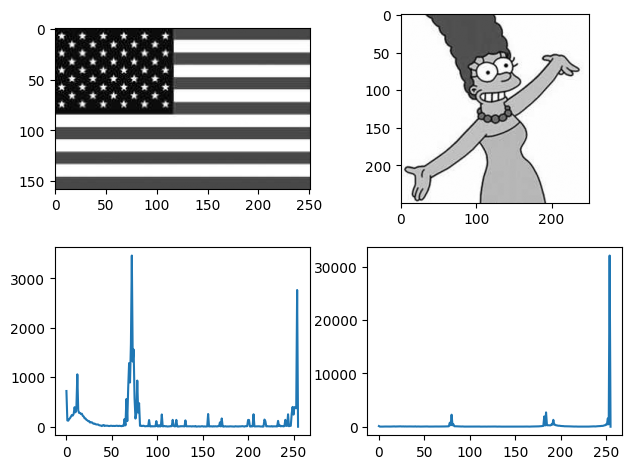

In [3]:
analizarCategoria('Bandera05')

La imagen es de la categoría Caricaturas.


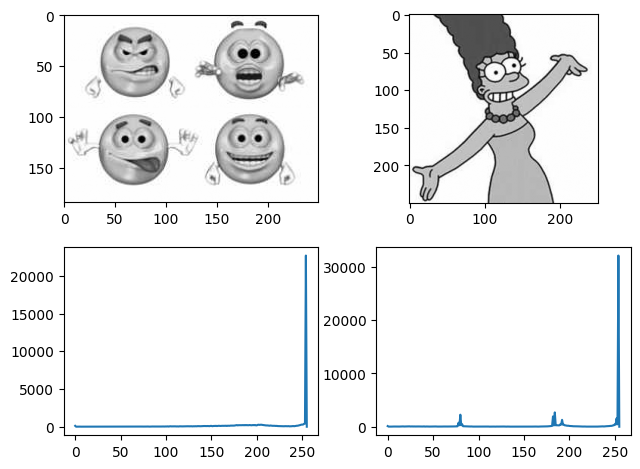

In [4]:
analizarCategoria('Caricaturas05')

La imagen es de la categoría Personaje.


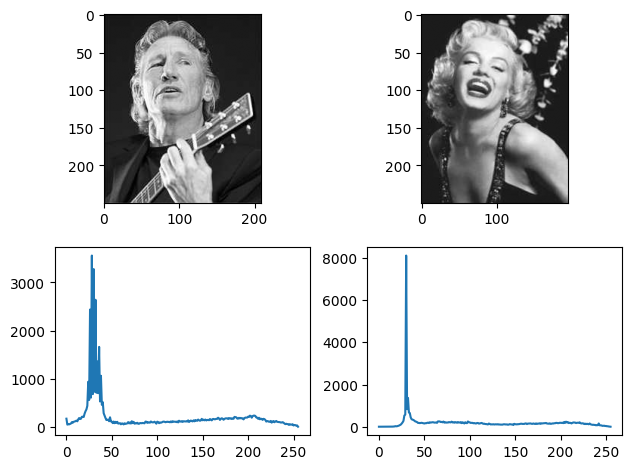

In [5]:
analizarCategoria('Personaje05')

La imagen es de la categoría Paisaje.


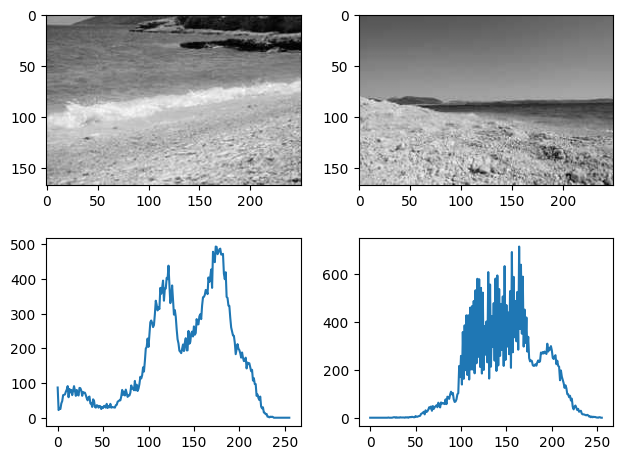

In [6]:
analizarCategoria('Paisaje05')